# Analysis in logistics

**Goal:**
To improve operational efficiency and reduce costs in the logistics network.

**Task:**

- Identify the main drivers of delivery delays and where they originate.
- Analyze route profitability and highlight underperforming routes.
- Evaluate driver costs and risks across fuel efficiency and safety incidents to identify high-cost and high-risk drivers.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

##  Data Loading

In [ ]:
trips = pd.read_csv('../data/trips.csv')
loads = pd.read_csv('../data/loads.csv')
routes = pd.read_csv('../data/routes.csv')
delivery_events = pd.read_csv('../data/delivery_events.csv')
driver_monthly_metrics = pd.read_csv('../data/driver_monthly_metrics.csv')
safety_incidents = pd.read_csv('../data/safety_incidents.csv')
drivers = pd.read_csv('../data/drivers.csv')
customers = pd.read_csv('../data/customers.csv')
maintenance_records = pd.read_csv('../data/maintenance_records.csv')
fuel_purchases = pd.read_csv('../data/fuel_purchases.csv')

## Data Overview

A quick look at the main tables used in this analysis: their structure, types, and any data quality issues worth noting before diving in.

### Trips 

In [ ]:
trips.head(5)

,trip_id,load_id,driver_id,truck_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status
0,TRIP00000001,LOAD00000001,DRV00117,TRK00035,TRL00167,2022-01-01,1314,26.20,183.80,7.15,3.50,Completed
1,TRIP00000002,LOAD00000002,DRV00141,TRK00108,TRL00082,2022-01-01,515,8.60,93.60,5.50,8.30,Completed
2,TRIP00000003,LOAD00000003,DRV00032,TRK00031,TRL00138,2022-01-01,2509,45.00,339.10,7.40,12.00,Completed
3,TRIP00000004,LOAD00000004,DRV00083,TRK00105,TRL00018,2022-01-01,717,11.10,110.30,6.50,9.60,Completed
4,TRIP00000005,LOAD00000005,DRV00044,TRK00076,TRL00054,2022-01-01,2243,35.00,328.90,6.82,11.60,Completed


In [8]:
trips.info()

<class 'pandas.DataFrame'>
RangeIndex: 85410 entries, 0 to 85409
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   trip_id                85410 non-null  str           
 1   load_id                85410 non-null  str           
 2   driver_id              83696 non-null  str           
 3   truck_id               83738 non-null  str           
 4   trailer_id             83730 non-null  str           
 5   dispatch_date          85410 non-null  datetime64[us]
 6   actual_distance_miles  85410 non-null  int64         
 7   actual_duration_hours  85410 non-null  float64       
 8   fuel_gallons_used      85410 non-null  float64       
 9   average_mpg            85410 non-null  float64       
 10  idle_time_hours        85410 non-null  float64       
 11  trip_status            85410 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(6)
memory usage: 7.8 MB

~2% trips have missing driver_id, truck_id, trailer_id. 
Likely unassigned trips at time of dispatch. Will keep rows 
but flag for context in driver/fleet analysis.

In [ ]:
trips['dispatch_date'] = pd.to_datetime(trips['dispatch_date'])

### Loads

In [49]:
loads.head(5)

,load_id,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,load_status,booking_type,total_revenue
0,LOAD00000001,CUST00183,RTE00019,2022-01-01,Dry Van,19178,13,"3,045.23",406.72,100,Completed,Spot,"3,551.95"
1,LOAD00000002,CUST00076,RTE00058,2022-01-01,Dry Van,27761,22,"1,224.48",98.61,0,Completed,Dedicated,"1,323.09"
2,LOAD00000003,CUST00027,RTE00048,2022-01-01,Refrigerated,35594,16,"7,171.12",792.88,0,Completed,Spot,"7,964.00"
3,LOAD00000004,CUST00088,RTE00013,2022-01-01,Refrigerated,33274,10,"1,308.20",141.33,50,Completed,Spot,"1,499.53"
4,LOAD00000005,CUST00185,RTE00020,2022-01-01,Dry Van,40257,10,"3,317.18",738.48,0,Completed,Spot,"4,055.66"


In [11]:
loads.info()

<class 'pandas.DataFrame'>
RangeIndex: 85410 entries, 0 to 85409
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   load_id              85410 non-null  str           
 1   customer_id          85410 non-null  str           
 2   route_id             85410 non-null  str           
 3   load_date            85410 non-null  datetime64[us]
 4   load_type            85410 non-null  str           
 5   weight_lbs           85410 non-null  int64         
 6   pieces               85410 non-null  int64         
 7   revenue              85410 non-null  float64       
 8   fuel_surcharge       85410 non-null  float64       
 9   accessorial_charges  85410 non-null  int64         
 10  load_status          85410 non-null  str           
 11  booking_type         85410 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(3), str(6)
memory usage: 7.8 MB


In [ ]:
loads['load_date'] = pd.to_datetime(loads['load_date'])

### Delivery Events

In [ ]:
delivery_events.head(5)

,event_id,load_id,trip_id,event_type,facility_id,scheduled_datetime,actual_datetime,detention_minutes,on_time_flag,location_city,location_state
0,EVT00000001,LOAD00000001,TRIP00000001,Pickup,FAC00034,2022-01-01 18:00:00.000000,2022-01-01 20:58:55.918185,0,False,Houston,TX
1,EVT00000002,LOAD00000001,TRIP00000001,Delivery,FAC00046,2022-01-02 23:10:55.918185,2022-01-02 21:30:22.142060,230,True,Detroit,MI
2,EVT00000003,LOAD00000002,TRIP00000002,Pickup,FAC00015,2022-01-01 18:00:00.000000,2022-01-01 17:37:26.608430,62,True,Kansas City,MO
3,EVT00000004,LOAD00000002,TRIP00000002,Delivery,FAC00050,2022-01-02 02:13:26.608430,2022-01-02 05:55:46.238257,67,False,Indianapolis,IN
4,EVT00000005,LOAD00000003,TRIP00000003,Pickup,FAC00001,2022-01-01 08:00:00.000000,2022-01-01 07:28:02.169634,83,True,Columbus,OH


In [16]:
delivery_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 170820 entries, 0 to 170819
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   event_id            170820 non-null  str           
 1   load_id             170820 non-null  str           
 2   trip_id             170820 non-null  str           
 3   event_type          170820 non-null  str           
 4   facility_id         170820 non-null  str           
 5   scheduled_datetime  170820 non-null  datetime64[us]
 6   actual_datetime     170820 non-null  datetime64[us]
 7   detention_minutes   170820 non-null  int64         
 8   on_time_flag        170820 non-null  bool          
 9   location_city       170820 non-null  str           
 10  location_state      170820 non-null  str           
dtypes: bool(1), datetime64[us](2), int64(1), str(7)
memory usage: 13.2 MB


In [ ]:
delivery_events['scheduled_datetime'] = pd.to_datetime(delivery_events['scheduled_datetime'])
delivery_events['actual_datetime'] = pd.to_datetime(delivery_events['actual_datetime'])

### Safety Incidents

In [ ]:
safety_incidents.head(5)

,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,"12,629.26",0.00,"12,629.26",True,Severe incident involving equipment
1,INC00000002,TRIP00032462,TRK00084,DRV00006,2023-02-19 11:00:00,Moving Violation,Columbus,NC,False,False,"2,700.70","14,284.24","16,984.94",False,Severe incident involving weather
2,INC00000003,TRIP00067583,TRK00106,DRV00119,2024-05-20 01:00:00,Customer Complaint,Seattle,OK,True,False,"24,302.32",0.00,"24,302.32",True,Minor incident involving traffic
3,INC00000004,TRIP00049128,TRK00085,DRV00134,2023-09-26 03:00:00,Equipment Damage,Kansas City,TN,True,False,"4,879.13",0.00,"4,879.13",True,Moderate incident involving equipment
4,INC00000005,TRIP00062884,TRK00014,DRV00133,2024-03-20 14:00:00,DOT Violation,Las Vegas,IN,False,False,"14,951.40",0.00,"14,951.40",False,Minor incident involving other driver


In [20]:
safety_incidents.info()

<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   incident_id          170 non-null    str           
 1   trip_id              170 non-null    str           
 2   truck_id             169 non-null    str           
 3   driver_id            169 non-null    str           
 4   incident_date        170 non-null    datetime64[us]
 5   incident_type        170 non-null    str           
 6   location_city        170 non-null    str           
 7   location_state       170 non-null    str           
 8   at_fault_flag        170 non-null    bool          
 9   injury_flag          170 non-null    bool          
 10  vehicle_damage_cost  170 non-null    float64       
 11  cargo_damage_cost    170 non-null    float64       
 12  claim_amount         170 non-null    float64       
 13  preventable_flag     170 non-null    bool     

In [ ]:
safety_incidents['incident_date'] = pd.to_datetime(safety_incidents['incident_date'])

# Task 1: Delivery Delays Analysis

**- Hypothesis**: Delays happen equally at pickup and delivery stages.

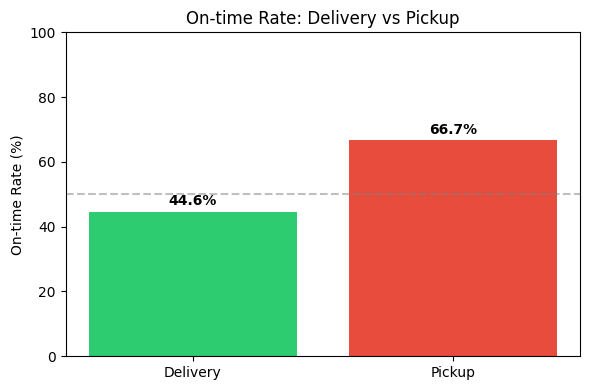

In [22]:
rates = delivery_events.groupby('event_type')['on_time_flag'].mean().mul(100)

plt.figure(figsize=(6, 4))
bars = plt.bar(rates.index, rates.values, color=['#2ecc71', '#e74c3c'])
plt.ylabel('On-time Rate (%)')
plt.title('On-time Rate: Delivery vs Pickup')
plt.ylim(0, 100)
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
for bar, value in zip(bars, rates.values):
    plt.text(bar.get_x() + bar.get_width()/2, value + 2, f'{value:.1f}%', 
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Result:** Not confirmed. Delivery on-time rate (44.6%) is much lower than pickup (66.7%), the delay problem is concentrated at the delivery stage, not pickup.

In [23]:
late_deliveries = delivery_events[
    (delivery_events['on_time_flag'] == False) & 
    (delivery_events['event_type'] == 'Delivery')
]
average_delay = (late_deliveries['actual_datetime'] - late_deliveries['scheduled_datetime']).mean()
print(average_delay)

0 days 02:42:57.254050


Scale of the problem: when deliveries are late, they miss the scheduled time by 2h 42min on average. That's not a minor slippage - it's substantial.

**- Hypothesis**: Long detention time at facilities causes delivery delays.

In [ ]:
print(delivery_events.groupby('on_time_flag')['detention_minutes'].mean())

on_time_flag
False   95.41
True    88.46
Name: detention_minutes, dtype: float64


**Result:** Not confirmed. Detention time is almost the same for late and on-time deliveries (95 vs 88 min, it's only 7 min gap).

**- Hypothesis:**  Delays are concentrated in specific locations (states, routes, or cities).

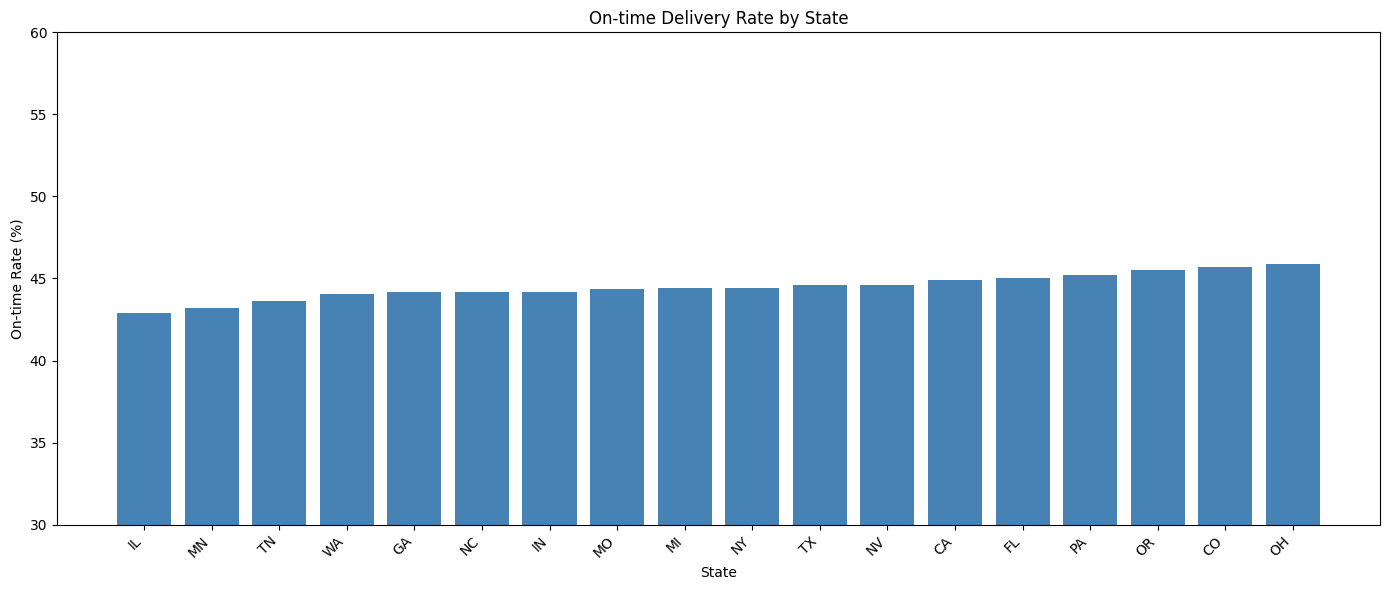

In [25]:
state_ontime = (delivery_events[delivery_events['event_type'] == 'Delivery']
    .groupby('location_state')['on_time_flag']
    .mean()
    .mul(100)
    .sort_values(ascending=True)
    .reset_index()
)

plt.figure(figsize=(14, 6))
plt.bar(state_ontime['location_state'], state_ontime['on_time_flag'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('On-time Delivery Rate by State')
plt.ylabel('On-time Rate (%)')
plt.xlabel('State')
plt.ylim(30, 60)
plt.tight_layout()
plt.show()


On-time rate sits in a narrow 42–45% range across all states. No state really stands out. Let's zoom in further to check if specific routes or cities tell a different story.

In [26]:
merged = delivery_events.merge(loads, on='load_id')
merged[merged['event_type'] == 'Delivery'].groupby('route_id')['on_time_flag'].mean().sort_values().head(10).reset_index().merge(routes, on='route_id')


,route_id,on_time_flag,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days
0,RTE00029,0.42,Seattle,WA,Charlotte,NC,2623,2.47,0.34,4
1,RTE00009,0.42,Dallas,TX,Indianapolis,IN,878,1.95,0.17,1
2,RTE00028,0.42,Seattle,WA,Houston,TX,2172,1.89,0.26,3
3,RTE00018,0.43,Philadelphia,PA,Indianapolis,IN,670,2.07,0.28,1
4,RTE00002,0.43,Atlanta,GA,Miami,FL,697,2.08,0.22,1
5,RTE00017,0.43,Philadelphia,PA,Minneapolis,MN,1130,1.81,0.34,1
6,RTE00051,0.43,Memphis,TN,Los Angeles,CA,1840,1.85,0.25,3
7,RTE00001,0.43,Atlanta,GA,Chicago,IL,677,1.70,0.19,1
8,RTE00052,0.43,Memphis,TN,Minneapolis,MN,804,1.63,0.34,1
9,RTE00033,0.43,Portland,OR,Seattle,WA,167,2.42,0.24,1


The worst routes are only 2–3 points below average. No single route is broken.

In [27]:
worst_origin = merged[merged['event_type'] == 'Delivery'].merge(routes, on='route_id').groupby('origin_city')['on_time_flag'].mean().sort_values().head(7)
worst_destination = merged[merged['event_type'] == 'Delivery'].merge(routes, on='route_id').groupby('destination_city')['on_time_flag'].mean().sort_values().head(7)

print("=== Worst Origin Cities ===")
print(worst_origin)
print("\n=== Worst Destination Cities ===")
print(worst_destination)

=== Worst Origin Cities ===
origin_city
Atlanta        0.43
Memphis        0.43
Seattle        0.43
Denver         0.44
Minneapolis    0.44
Philadelphia   0.44
Columbus       0.44
Name: on_time_flag, dtype: float64

=== Worst Destination Cities ===
destination_city
Chicago       0.43
Minneapolis   0.43
Memphis       0.44
Seattle       0.44
Houston       0.44
Atlanta       0.44
Charlotte     0.44
Name: on_time_flag, dtype: float64


**Result:** Not confirmed. At every level of granularity - states (42–45%), routes (42.4–43.2%), and cities (42.9–44.4%) - the on-time rate is uniformly low. The problem isn't geographic - it's across the whole network.

**- Hypothesis:** Longer routes have lower on-time rates.

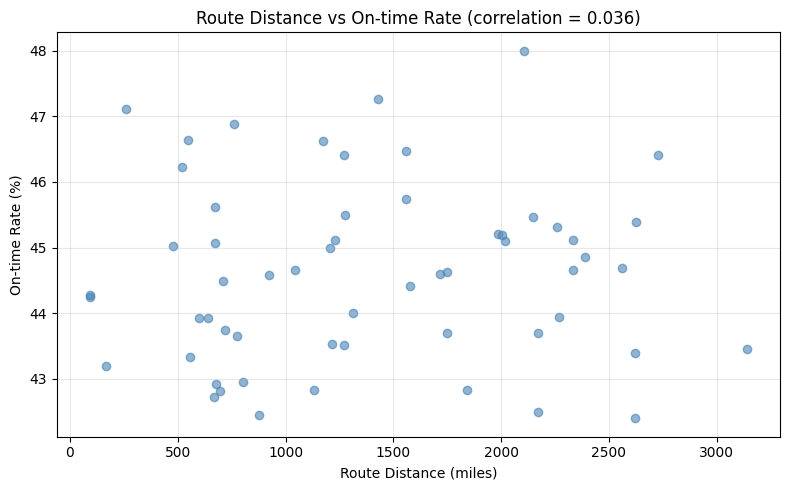

In [28]:
route_analysis = (
    delivery_events
    .merge(loads[['load_id', 'route_id']], on='load_id')
    .merge(routes[['route_id', 'typical_distance_miles']], on='route_id')
    .query('event_type == "Delivery"')
    .groupby('route_id')
    .agg(
      on_time_rate=('on_time_flag', 'mean'), 
      distance=('typical_distance_miles', 'first')
      )
).reset_index()

correlation = route_analysis['distance'].corr(route_analysis['on_time_rate'])

plt.figure(figsize=(8, 5))
plt.scatter(route_analysis['distance'], route_analysis['on_time_rate']*100, 
            alpha=0.6, color='steelblue')
plt.xlabel('Route Distance (miles)')
plt.ylabel('On-time Rate (%)')
plt.title(f'Route Distance vs On-time Rate (correlation = {correlation:.3f})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Correlation between on-time delivery rate and route distance is very weak (close to 0), suggesting that distance alone does not significantly impact delivery timeliness.

**Result:** Correlation = 0.036 - not confirmed

**- Hypothesis:** Driver experience or performance affects on-time delivery rate.

Top 10 avg: 48.3%
Bottom 10 avg: 40.8%
Gap: 7.5 percentage points


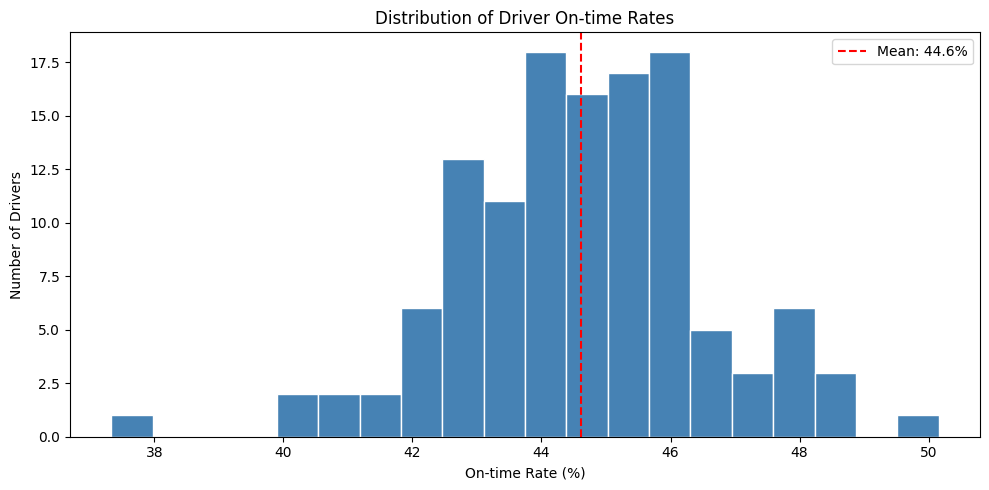

In [29]:
driver_performance = (
    delivery_events.merge(trips[['trip_id', 'driver_id']], on='trip_id')
    .query('event_type == "Delivery"')
    .groupby('driver_id')
    .agg(on_time_rate=('on_time_flag', 'mean'), deliveries=('on_time_flag', 'count'))
    .query('deliveries >= 50')
).reset_index().merge(drivers[['driver_id', 'first_name', 'last_name']], on='driver_id')

top_10 = driver_performance.nlargest(10, 'on_time_rate')['on_time_rate'].mean()
bot_10 = driver_performance.nsmallest(10, 'on_time_rate')['on_time_rate'].mean()
mean_rate = driver_performance['on_time_rate'].mean()

print(f"Top 10 avg: {top_10:.1%}")
print(f"Bottom 10 avg: {bot_10:.1%}")
print(f"Gap: {(top_10 - bot_10)*100:.1f} percentage points")

plt.figure(figsize=(10, 5))
plt.hist(driver_performance['on_time_rate']*100, bins=20, 
         color='steelblue', edgecolor='white')
plt.axvline(mean_rate*100, color='red', linestyle='--', 
            label=f'Mean: {mean_rate*100:.1f}%')
plt.xlabel('On-time Rate (%)')
plt.ylabel('Number of Drivers')
plt.title('Distribution of Driver On-time Rates')
plt.legend()
plt.tight_layout()
plt.show()




**Result:** Weakly confirmed. Gap between top 10 and bottom 10 drivers is 7.5 pp (48.3% vs 40.8%), drivers do have some impact, but not enough to explain the overall 55% delay rate.

**- Hypothesis:** Load type affects on-time delivery rate. 

In [30]:
ontime_by_loadtype = (
    delivery_events.merge(loads[['load_id', 'load_type']], on='load_id')
    .query('event_type == "Delivery"')
    .groupby('load_type')['on_time_flag']
    .mean()
    .sort_values()
)
print(ontime_by_loadtype)

load_type
Dry Van        0.45
Refrigerated   0.45
Name: on_time_flag, dtype: float64


**Result:** Not confirmed. Load types are virtually identical. Load type has no impact on delivery timeliness.

**- Hypothesis:** On-time rate depends on the customer receiving the delivery.

                      on_time_rate  deliveries
customer_name                                 
ABC Retail                    0.51         412
Premier Logistics             0.50         419
Global Manufacturing          0.48         800
ABC Manufacturing             0.48         852
Elite Supply Chain            0.47         429
...                            ...         ...
Elite Distribution            0.41         435
XYZ Corp                      0.41         428
Superior Corp                 0.41         437
Continental Group             0.40         481
Superior Retail               0.40         400

[107 rows x 2 columns]


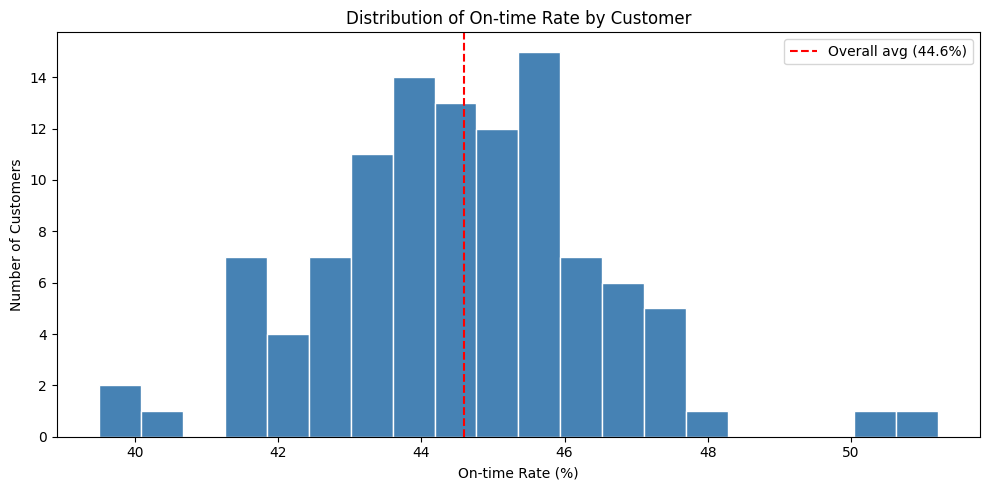

In [31]:
ontime_by_customer = ( 
    delivery_events.merge(loads[['load_id', 'customer_id']], on='load_id')
    .merge(customers[['customer_id', 'customer_name']], on='customer_id')
    .query('event_type == "Delivery"')
    .groupby('customer_name')
    .agg(
        on_time_rate=('on_time_flag', 'mean'),
        deliveries=('on_time_flag', 'count')
    )
    .sort_values('on_time_rate', ascending=False)
)
print(ontime_by_customer)
plt.figure(figsize=(10, 5))
plt.hist(ontime_by_customer['on_time_rate']*100, bins=20, 
         color='steelblue', edgecolor='white')
plt.axvline(44.6, color='red', linestyle='--', label='Overall avg (44.6%)')
plt.xlabel('On-time Rate (%)')
plt.ylabel('Number of Customers')
plt.title('Distribution of On-time Rate by Customer')
plt.legend()
plt.tight_layout()
plt.show()


**Result:** Confirmed. On-time rate ranges from 39.5% to 51.2% across 107 customers - a 12 pp gap, the strongest signal in the analysis. Each customer has at least 388 deliveries, so this is not a sample size artifact. Customer identity is the main driver of variation in delivery performance.

**- Hypothesis:** Customers with poor unloading organization cause higher detention times, leading to delays.

In [32]:
detention_by_customer = (
    delivery_events
    .merge(loads[['load_id', 'customer_id']], on='load_id')
    .merge(customers[['customer_id', 'customer_name']], on='customer_id')
    .query('event_type == "Delivery"')
    .groupby('customer_name')
    .agg(
        avg_detention=('detention_minutes', 'mean'),
        deliveries=('detention_minutes', 'count')
    )
)
print(detention_by_customer.sort_values('avg_detention', ascending=False))
    

                          avg_detention  deliveries
customer_name                                      
Premier Supply Chain             114.00         415
XYZ Logistics                    113.95         879
Continental Industries           113.85         442
United Corp                      112.68         460
Superior Distribution            111.77         903
...                                 ...         ...
Superior Industries              102.36         415
Continental Distribution         102.17         443
Premier Foods                    100.06         429
Elite Wholesale                   99.96         408
National Industries               98.31         420

[107 rows x 2 columns]


**Result:**  Not confirmed. Detention times vary only slightly across customers (98-114 min, a 16 min gap). Not enough to explain the 12pp difference in on-time rates.

**- Hypothesis:** Time of day affects on-time delivery rate by customers.

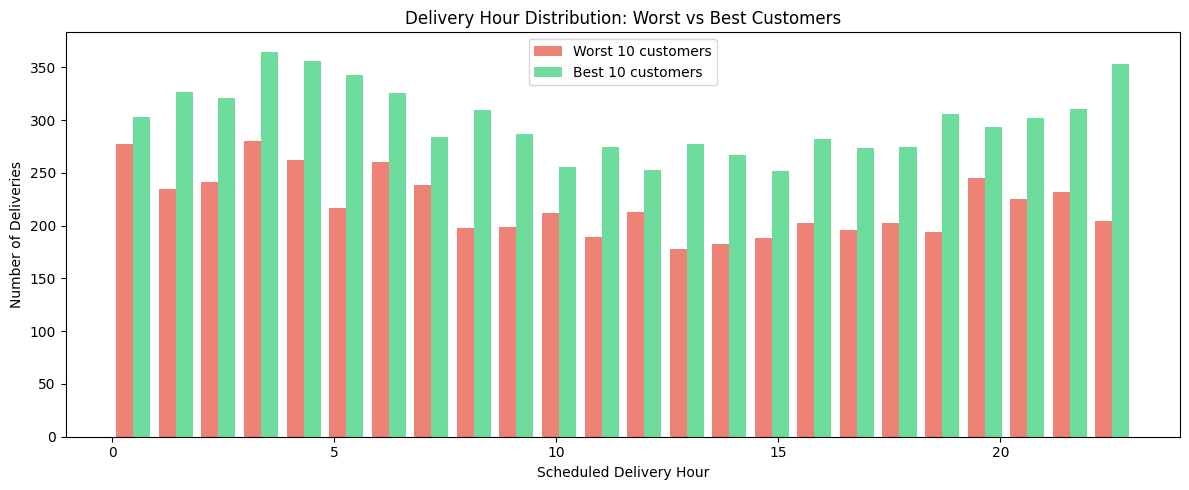

In [33]:
best_customers = ontime_by_customer.head(10).index.tolist()
worst_customers = ontime_by_customer.tail(10).index.tolist()

dlv_with_customer = (delivery_events
    .merge(loads[['load_id', 'customer_id']], on='load_id')
    .merge(customers[['customer_id', 'customer_name']], on='customer_id')
    .query('event_type == "Delivery"')
    .copy())

dlv_with_customer['hour'] = dlv_with_customer['scheduled_datetime'].dt.hour

worst_hours = dlv_with_customer[dlv_with_customer['customer_name'].isin(worst_customers)]['hour']
best_hours = dlv_with_customer[dlv_with_customer['customer_name'].isin(best_customers)]['hour']

plt.figure(figsize=(12, 5))
plt.hist([worst_hours, best_hours], bins=24, label=['Worst 10 customers', 'Best 10 customers'],
         color=['#e74c3c', '#2ecc71'], alpha=0.7)
plt.xlabel('Scheduled Delivery Hour')
plt.ylabel('Number of Deliveries')
plt.title('Delivery Hour Distribution: Worst vs Best Customers')
plt.legend()
plt.tight_layout()
plt.show()

**Result:** Not confirmed. Delivery hour distribution is nearly identical for best and worst customers, time of day does not explain the performance gap.


In [34]:
dlv = delivery_events[delivery_events['event_type'] == 'Delivery'].copy()
dlv['month'] = dlv['scheduled_datetime'].dt.month
print(dlv.groupby('month')['on_time_flag'].mean().round(3))

month
1    0.45
2    0.44
3    0.44
4    0.45
5    0.45
6    0.45
7    0.45
8    0.44
9    0.44
10   0.46
11   0.44
12   0.44
Name: on_time_flag, dtype: float64


Quick seasonality check: on-time rate is stable across all months (43-45%). No weather/season effect visible in the data.

## Conclusion — Delivery Delays

Only 44.6% of deliveries arrive on time, and when they're late, they miss the schedule by an average of 2 hours 42 minutes. That's the headline problem, but the cause turned out to be harder to pin down than expected.

I tested eleven hypotheses across the obvious operational suspects: pickup vs delivery stage, detention time at facilities, geography (states, routes, cities), route distance, driver performance, load type, customer identity, customer detention, time of day, and seasonality. Almost none of these explain the gap. On-time rate sits in a narrow 42 to 45% band no matter how the data is sliced.

The one factor that does stand out is the **customer**. On-time rate ranges from 39.5% to 51.2% across 107 customers, a 12 percentage point gap, which is several times bigger than anything else I tested. Each customer has at least 388 deliveries behind them, so this isn't a small sample artifact. It's a real, consistent pattern.

What I expected to find, that bad customers have slow unloading or get deliveries scheduled at awkward hours, turned out not to be the case. Detention times barely differ between best and worst customers (16 min gap). Delivery hour distributions look nearly identical too. So the customer effect is real, but its mechanism isn't visible in this dataset. Most likely it lives in things we don't have here: appointment window strictness, receiver availability, internal facility procedures, or SLA terms that vary by client.

A small additional signal comes from drivers, where the top 10 and bottom 10 differ by 7.5 percentage points (48.3% vs 40.8%). It's real but small, and notably even the best drivers stay below 50%. This suggests the issue isn't individual performance but something systemic that affects everyone roughly equally.

### What this means in practice

The data tells us where to look and where not to. Investing in driver retraining, route optimization, or detention reduction won't move the needle. Those aren't the cause. The most actionable lever is on the receiver side. Working with the worst 10 to 15 customers to understand what specifically makes deliveries to them late could plausibly improve overall on-time performance by 5 to 10 points without any changes to internal operations.

To get a real answer on the remaining 55% baseline delay, more data is needed: weather, traffic, customer SLAs, and appointment window policies. None of that is in this dataset, and that's an important finding in itself. The operational data alone doesn't contain the answer.

# Task 2: Route profitability

Quick note on how the numbers below are calculated.

Revenue is straightforward: it's the sum of base revenue, fuel surcharge, and accessorial charges from the loads table.

Cost was trickier. The dataset doesn't have payroll, so I built it from three pieces:
- Fuel: gallons used * average price per gallon.
- Driver pay: $0.60/mile, which is roughly the US industry average for long-haul
- Maintenance: total fleet maintenance / total fleet miles, applied per trip

Profit = revenue - cost, calculated per trip and then aggregated by route.

The model doesn't include truck depreciation, insurance, tolls, or overhead, so these numbers are useful for comparing routes against each other, not for showing the company's true bottom line.

In [ ]:
loads['total_revenue'] = loads['revenue'] + loads['fuel_surcharge'] + loads['accessorial_charges']
print(loads[['load_id', 'total_revenue']].head())
print(f"\nMean total revenue per load: ${loads['total_revenue'].mean():.2f}")

        load_id  total_revenue
0  LOAD00000001       3,551.95
1  LOAD00000002       1,323.09
2  LOAD00000003       7,964.00
3  LOAD00000004       1,499.53
4  LOAD00000005       4,055.66

Mean total revenue per load: $3496.33


Driver cost estimated at $0.60/mile, U.S. industry average for 2022-2024.

In [ ]:
# Calculate fuel costs
avg_price = fuel_purchases['price_per_gallon'].mean()
trips['fuel_cost'] = trips['fuel_gallons_used'] * avg_price


# Calculate driver costs (assuming $0.60/mile)
trips['driver_cost'] = trips['actual_distance_miles'] * 0.60

# Calculate maintenance costs 
maint_per_mile = maintenance_records['total_cost'].sum() / trips['actual_distance_miles'].sum()
trips['maintenance_cost'] = trips['actual_distance_miles'] * maint_per_mile

print(trips[[ 'trip_id', 'actual_distance_miles','fuel_cost', 'driver_cost', 'maintenance_cost']].head())


        trip_id  actual_distance_miles  fuel_cost  driver_cost  \
0  TRIP00000001                   1314     716.53       788.40   
1  TRIP00000002                    515     364.89       309.00   
2  TRIP00000003                   2509   1,321.95     1,505.40   
3  TRIP00000004                    717     430.00       430.20   
4  TRIP00000005                   2243   1,282.19     1,345.80   

   maintenance_cost  
0             61.64  
1             24.16  
2            117.70  
3             33.63  
4            105.22  


In [ ]:
trips['total_cost'] = trips['fuel_cost'] + trips['driver_cost'] + trips['maintenance_cost']
print(trips[['trip_id', 'total_cost']].head())
print(f"\nMean total cost per trip: ${trips['total_cost'].mean():.2f}")

        trip_id  total_cost
0  TRIP00000001    1,566.57
1  TRIP00000002      698.05
2  TRIP00000003    2,945.05
3  TRIP00000004      893.83
4  TRIP00000005    2,733.21

Mean total cost per trip: $1790.03


In [ ]:
trip_pnl = trips.merge(loads[['load_id', 'total_revenue', 'route_id']], on='load_id')
trip_pnl['profit'] = trip_pnl['total_revenue'] - trip_pnl['total_cost']

print(trip_pnl[['trip_id', 'total_revenue', 'total_cost', 'profit']].head())
print(f"\nMean profit per trip: ${trip_pnl['profit'].mean():.2f}")
print(f"Trips with negative profit: {(trip_pnl['profit'] < 0).sum()}")

        trip_id  total_revenue  total_cost   profit
0  TRIP00000001       3,551.95    1,566.57 1,985.38
1  TRIP00000002       1,323.09      698.05   625.04
2  TRIP00000003       7,964.00    2,945.05 5,018.95
3  TRIP00000004       1,499.53      893.83   605.70
4  TRIP00000005       4,055.66    2,733.21 1,322.45

Mean profit per trip: $1706.30
Trips with negative profit: 0


Average profit per trip is $1,706, with **zero trips operating at a loss**. The cost model used (fuel + driver + maintenance) shows the company is profitable on every shipment.

In [39]:
profitable_routes = (
    trip_pnl
    .merge(routes[['route_id', 'origin_city', 'destination_city', 'typical_distance_miles']], on='route_id')
    .groupby(['route_id', 'origin_city', 'destination_city'])
    .agg(
      total_profit=('profit', 'sum'),
      trip_count=('trip_id', 'count'),
      avg_profit_per_trip=('profit', 'mean'),
      distance=('typical_distance_miles', 'first')
    )
    .reset_index()
)

print(f"Total routes: {len(profitable_routes)}")
print(profitable_routes.describe())



Total routes: 58
       total_profit  trip_count  avg_profit_per_trip  distance
count         58.00       58.00                58.00     58.00
mean   2,512,669.19    1,472.59             1,708.91  1,391.50
std    1,698,595.73       38.06             1,151.62    782.83
min      175,491.30    1,386.00               119.54     92.00
25%    1,160,232.15    1,447.75               789.27    700.75
50%    2,126,752.42    1,472.00             1,451.64  1,271.00
75%    3,455,474.01    1,491.00             2,366.61  2,085.25
max    6,448,477.22    1,628.00             4,573.39  3,141.00


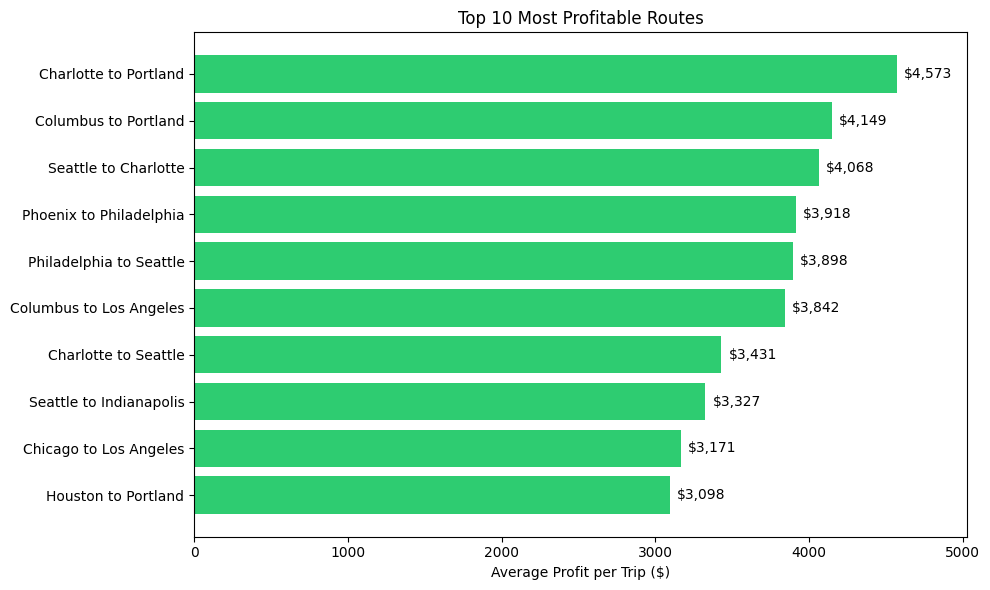

In [40]:
top10 = (profitable_routes
    .nlargest(10, 'avg_profit_per_trip')
    .sort_values('avg_profit_per_trip', ascending=True)
    .copy()
)
top10['route_label'] = top10['origin_city'] + ' to ' + top10['destination_city']

plt.figure(figsize=(10, 6))
bars = plt.barh(top10['route_label'], top10['avg_profit_per_trip'], color='#2ecc71')
plt.bar_label(bars, fmt='${:,.0f}', padding=5)
plt.xlim(0, top10['avg_profit_per_trip'].max() * 1.1)
plt.xlabel('Average Profit per Trip ($)')
plt.title('Top 10 Most Profitable Routes')
plt.tight_layout()
plt.show()

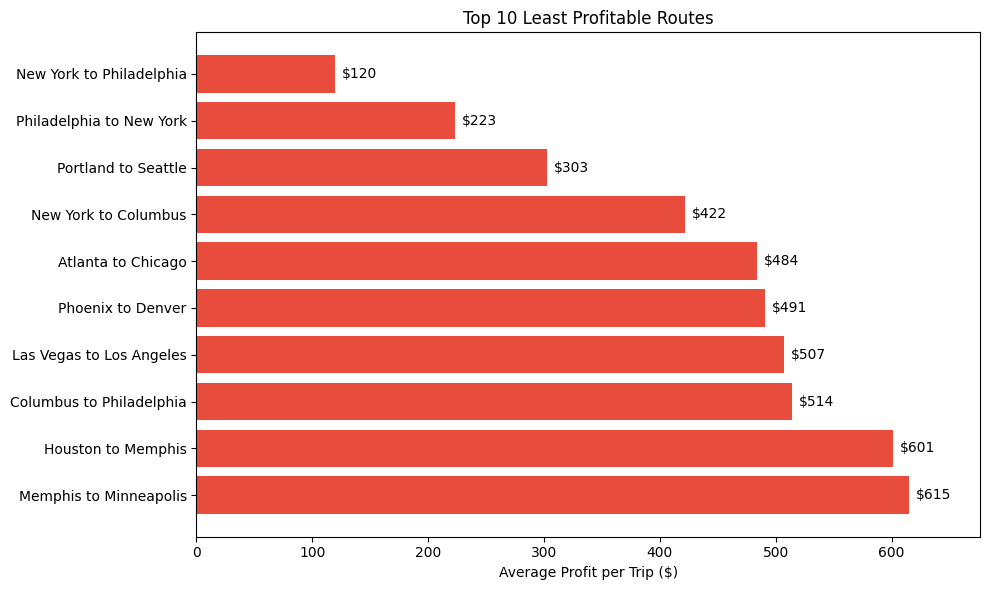

In [41]:
bot10 = (profitable_routes  
    .nsmallest(10, 'avg_profit_per_trip')
    .sort_values('avg_profit_per_trip', ascending=False)
    .copy()
)
bot10['route_label'] = bot10['origin_city'] + ' to ' + bot10['destination_city']
plt.figure(figsize=(10, 6))
bars = plt.barh(bot10['route_label'], bot10['avg_profit_per_trip'], color='#e74c3c')
plt.bar_label(bars, fmt='${:,.0f}', padding=5)
plt.xlim(0, bot10['avg_profit_per_trip'].max() * 1.1)
plt.xlabel('Average Profit per Trip ($)')
plt.title('Top 10 Least Profitable Routes')
plt.tight_layout()
plt.show()


Top 10 routes generate $3,000-$4,500 profit per trip. Bottom 10 routes also remain profitable, generating $700-$1,200 per trip, every route in the network is profit-making, but the gap between best and worst is significant (approx. 3-4× difference). This raises the question: what drives the difference?

**- Hypothesis:** Long-distance routes are more profitable than shorter. 

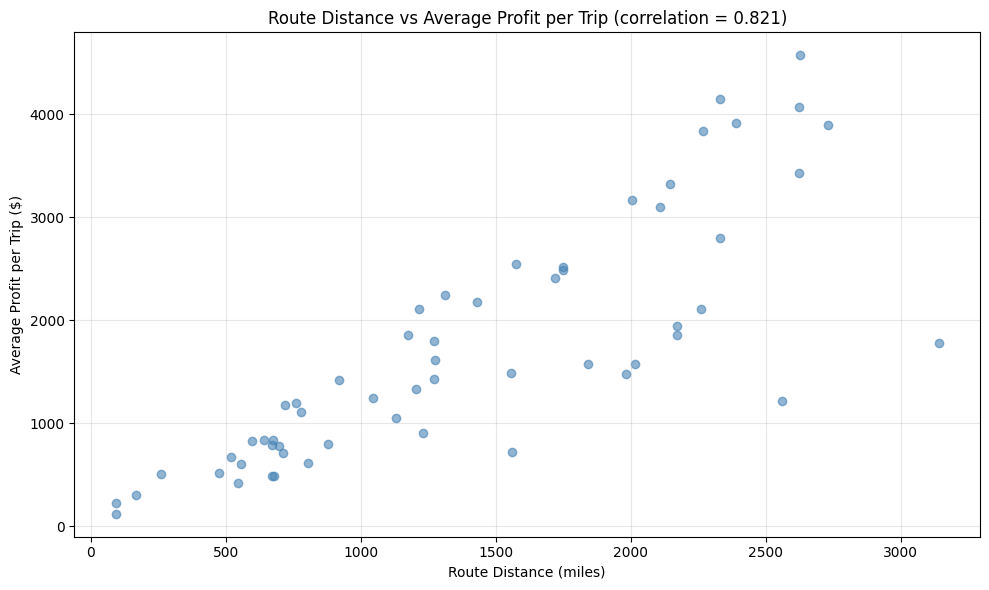

In [42]:
correlation = profitable_routes['distance'].corr(profitable_routes['avg_profit_per_trip'])

plt.figure(figsize=(10, 6))
plt.scatter(profitable_routes['distance'], 
            profitable_routes['avg_profit_per_trip'], 
            alpha=0.6, 
            color='steelblue')
plt.xlabel('Route Distance (miles)')
plt.ylabel('Average Profit per Trip ($)')
plt.title(f'Route Distance vs Average Profit per Trip (correlation = {correlation:.3f})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Result:** Confirmed. Strong positive correlation (0.82) between route distance and average profit per trip. Longer routes are systematically more profitable, likely because fixed costs (loading, documentation, dispatch) are spread over more miles, increasing margin per trip. This explains why the top 10 routes are dominated by long-haul (From Charlotte to Portland 2500+ miles, from Phoenix to Philadelphia 2300+ miles).

**- Hypothesis:** Booking type affects route profitability.

In [ ]:
profit_by_booking = (
    trip_pnl
    .merge(loads[['load_id', 'booking_type']], on='load_id')
    .groupby('booking_type')
    .agg(
        avg_profit_per_trip=('profit', 'mean'),
        trip_count=('trip_id', 'count'),
        total_profit=('profit', 'sum')
    )
    .reset_index()
)

print(profit_by_booking)


  booking_type  avg_profit_per_trip  trip_count  total_profit
0     Contract             1,699.92       21545 36,624,703.04
1    Dedicated             1,707.74       42337 72,300,415.16
2         Spot             1,709.85       21528 36,809,694.86


**Result:** Not confirmed. All three booking types produce nearly identical profit per trip ($1,700-$1,710). The 0.6% spread is noise,booking type doesn't drive profitability.

In [ ]:
total_revenue = trip_pnl['total_revenue'].sum()
total_cost = trip_pnl['total_cost'].sum()  
total_profit = trip_pnl['profit'].sum()
margin = total_profit / total_revenue * 100 

print(f"Total revenue: ${total_revenue:,.0f}")
print(f"Total cost: ${total_cost:,.0f}")
print(f"Total profit: ${total_profit:,.0f}")
print(f"Profit margin: {margin:.1f}%")

Total revenue: $298,621,429
Total cost: $152,886,616
Total profit: $145,734,813
Profit margin: 48.8%


## Conclusion — Route Profitability

The company is profitable. Over the analyzed period it generated $298.6M in revenue and $145.7M in profit on a unit economics basis, with a margin of 48.8%. That number is high for trucking (the industry usually runs at 5 to 15%), but it makes sense given the cost model is partial. More on that at the end. All 85,410 trips made money, and all 58 routes are in the black on paper.

What's more interesting is the spread inside that healthy picture. Top routes like Charlotte to Portland bring in around $4,573 per trip. The bottom of the list is much lower, with the worst routes earning just $120 to $600. That's a 38 times gap inside a network that on the surface all looks fine.

The driver of this difference is simple. It's distance. Correlation between route length and profit per trip is 0.82. Longer routes are systematically more profitable because fixed costs like loading, dispatch and documentation get spread over more miles. The top 10 are almost entirely long-haul lanes of 2,000 to 2,500 miles. The bottom is dominated by short city-to-city routes like New York to Philadelphia, where fixed costs eat almost the entire margin.

I also checked whether booking type matters. Spot, Contract, or Dedicated. It doesn't. All three produce essentially identical profit per trip ($1,700 to $1,710). The portfolio mix of bookings is fine, no need to chase one type over another.

### What this means in practice

The clear lever is long-haul. Longer routes simply produce more profit per truck and per driver, and where there's flexibility in dispatch, leaning into them is the most direct path to higher margins.

The short underperforming routes need more attention than the numbers suggest. At $120 to $300 per trip, the margin is so thin that any small disruption probably turns them unprofitable. And given that the cost model here excludes tolls, depreciation, insurance, and overhead, some of these lanes are likely already losing money in reality. Tolls alone on a corridor like New York to Philadelphia can run $50 to $100 per trip, which would wipe out the $120 profit shown in the model. The reasonable options are renegotiating rates with customers, bundling short trips to reduce overhead per delivery, or deprioritizing these lanes when capacity is tight.

A note on the cost model. Driver pay was set at $0.60 per mile (the U.S. industry standard, since payroll isn't in the dataset), and the model excludes truck depreciation, insurance, tolls, and overhead. These are significant gaps, which is why the 48.8% margin looks much higher than what a real trucking company would book. The actual bottom line is much lower. What still holds up is the relative comparison between routes. A route that looks more profitable here would still be more profitable in a fuller model.

# Task 3: Driver Cost & Risk Analysis


**-Hypothesis:** Some drivers consistently use more fuel per mile than others, costing the company significantly more on fuel.

In [ ]:
driver_mpg = (
    driver_monthly_metrics
    .groupby('driver_id')
    .agg(
        avg_mpg=('average_mpg', 'mean'),
        total_miles=('total_miles', 'sum'),
        total_fuel_gallons=('total_fuel_gallons', 'sum')
    ).reset_index()
)

avg_price = fuel_purchases['price_per_gallon'].mean()
driver_mpg['fuel_cost'] = driver_mpg['total_fuel_gallons'] * avg_price
driver_mpg['fuel_cost_per_mile'] = driver_mpg['fuel_cost'] / driver_mpg['total_miles']

# Comparing each driver to the fleet average.

fleet_mpg = driver_mpg['avg_mpg'].mean()
driver_mpg['expected_fuel'] = driver_mpg['total_miles'] / fleet_mpg
driver_mpg['excess_fuel_gallons'] = driver_mpg['total_fuel_gallons'] - driver_mpg['expected_fuel']
driver_mpg['excess_fuel_cost'] = driver_mpg['excess_fuel_gallons'] * avg_price


print(f"Fleet average MPG: {fleet_mpg:.2f}")
print(f"\nMost expensive drivers:")
print(driver_mpg.nlargest(10, 'excess_fuel_cost')[
    ['driver_id', 'avg_mpg', 'total_miles', 'excess_fuel_cost']
].round(2))
print(driver_mpg.nsmallest(10, 'excess_fuel_cost')[
    ['driver_id', 'avg_mpg', 'total_miles', 'excess_fuel_cost']
].round(2))

Fleet average MPG: 6.50

Most expensive drivers:
    driver_id  avg_mpg  total_miles  excess_fuel_cost
93   DRV00113     6.44       951982         11,092.81
108  DRV00130     6.46       973944         10,837.84
94   DRV00114     6.47      1023278          9,499.23
123  DRV00150     6.46       973942          8,835.26
6    DRV00009     6.49       966516          8,716.49
27   DRV00033     6.48       958305          8,696.49
57   DRV00070     6.48       973415          8,687.33
45   DRV00056     6.48       979155          8,658.38
10   DRV00013     6.48       986215          8,471.48
20   DRV00024     6.49      1009793          8,444.01
    driver_id  avg_mpg  total_miles  excess_fuel_cost
89   DRV00109     6.56       953178         -2,945.19
50   DRV00061     6.54       939390           -933.13
86   DRV00105     6.56       973771           -855.43
33   DRV00039     6.54       965658            154.63
46   DRV00057     6.55       911374            201.78
65   DRV00081     6.55       9467

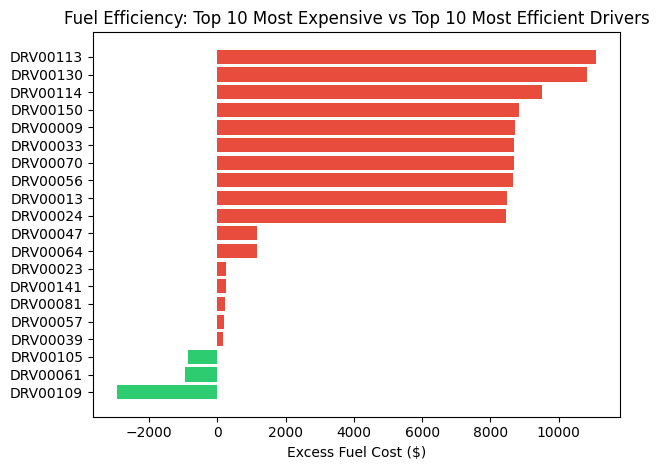

In [46]:
top_drivers = driver_mpg.nlargest(10, 'excess_fuel_cost')
bottom_drivers = driver_mpg.nsmallest(10, 'excess_fuel_cost')

combined = pd.concat([top_drivers, bottom_drivers])


combined = combined.sort_values('excess_fuel_cost')
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in combined['excess_fuel_cost']]
plt.barh(combined['driver_id'], combined['excess_fuel_cost'], color=colors);

plt.xlabel('Excess Fuel Cost ($)')
plt.title('Fuel Efficiency: Top 10 Most Expensive vs Top 10 Most Efficient Drivers')
plt.tight_layout()
plt.show()


**Result:** Not confirmed. Fuel cost per mile is essentially the same across all drivers ($0.60 vs $0.61, just a 1 cent spread). The variation is too small to justify driver-focused interventions like training programs or route reassignments based on fuel efficiency.

**- Hypothesis:** A few high-risk drivers generate most of the company's incident-related costs.  

In [47]:
driver_risk = (
    safety_incidents
    .groupby('driver_id')
    .agg(
        incident_count=('incident_id', 'count'),
        at_fault_count=('at_fault_flag', 'sum'),
        total_vehicle_damage=('vehicle_damage_cost', 'sum'),
        total_cargo_damage=('cargo_damage_cost', 'sum')
    )
    .reset_index()
)

driver_risk['total_damage'] = driver_risk['total_vehicle_damage'] + driver_risk['total_cargo_damage']

driver_risk = driver_risk.merge(driver_mpg[['driver_id', 'total_miles']], on='driver_id')
driver_risk['at_fault_per_100k_miles'] = driver_risk['at_fault_count'] / driver_risk['total_miles'] * 100000

# Key metrics
total_damage_sum = driver_risk['total_damage'].sum()
top10_damage = driver_risk.nlargest(10, 'total_damage')['total_damage'].sum()
print(f"Total damage across fleet: ${total_damage_sum:,.0f}")
print(f"Top 10 drivers account for {top10_damage/total_damage_sum*100:.1f}% of all damage")
print(f"Drivers with incidents: {len(driver_risk)} of 150")

# Two angles on problem drivers
print("\nTop 5 by total damage:")
print(driver_risk.sort_values('total_damage', ascending=False).head(5))
print("\nTop 5 by at-fault incidents:")
print(driver_risk.sort_values('at_fault_count', ascending=False).head(5))
print("\nTop 5 by at-fault incidents per 100k miles:")
print(driver_risk.sort_values('at_fault_per_100k_miles', ascending=False).head(5))

Total damage across fleet: $2,653,172
Top 10 drivers account for 30.5% of all damage
Drivers with incidents: 92 of 150

Top 5 by total damage:
   driver_id  incident_count  at_fault_count  total_vehicle_damage  \
36  DRV00058               7               2            102,013.22   
84  DRV00142               2               2             24,261.80   
7   DRV00012               3               0             19,968.99   
54  DRV00094               2               1             28,429.95   
58  DRV00100               3               1             38,814.69   

    total_cargo_damage  total_damage  total_miles  at_fault_per_100k_miles  
36           15,568.53    117,581.75       938388                     0.21  
84           88,444.20    112,706.00       999565                     0.20  
7            84,932.55    104,901.54       836187                     0.00  
54           60,483.65     88,913.60       969301                     0.10  
58           43,317.06     82,131.75       976313  

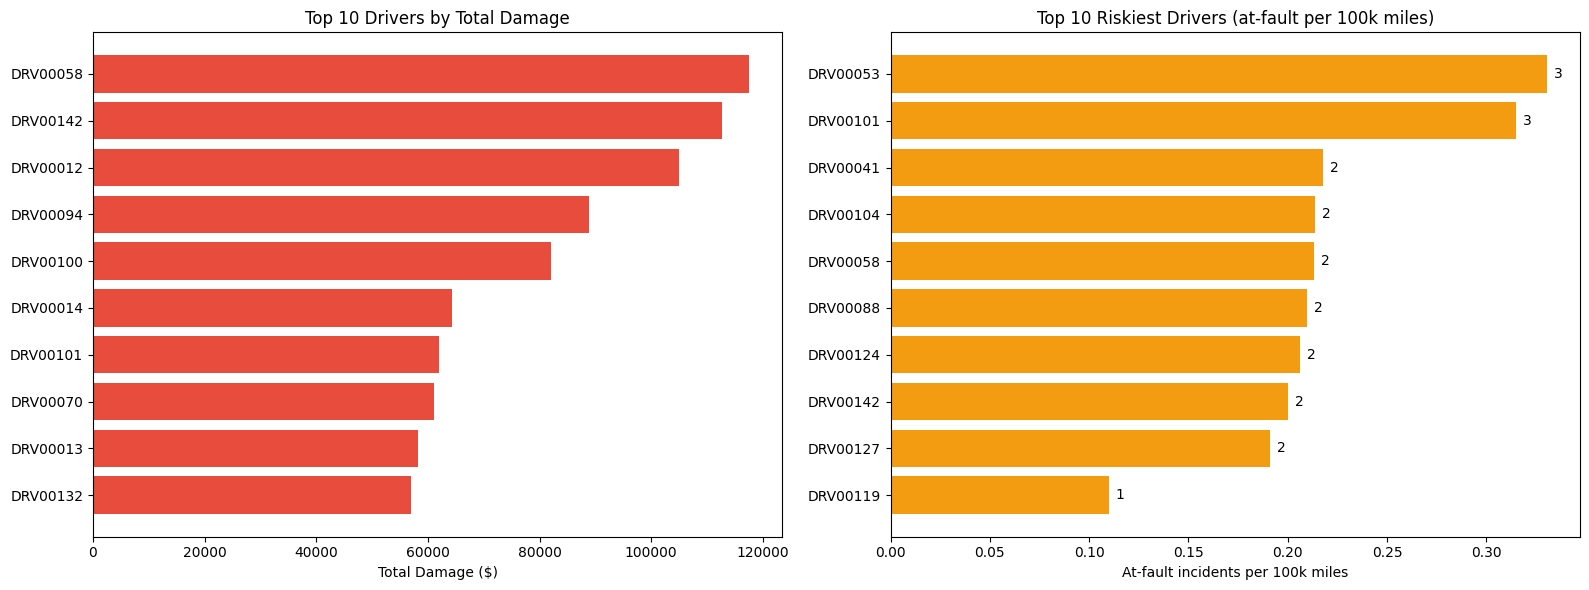

In [48]:
top_damage = driver_risk.nlargest(10, 'total_damage').sort_values('total_damage', ascending=True)
top_risky = driver_risk.nlargest(10, 'at_fault_per_100k_miles').sort_values('at_fault_per_100k_miles', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_damage['driver_id'], top_damage['total_damage'], color='#e74c3c')
axes[0].set_xlabel('Total Damage ($)')
axes[0].set_title('Top 10 Drivers by Total Damage')

axes[1].barh(top_risky['driver_id'], top_risky['at_fault_per_100k_miles'], color='#f39c12')
bars = axes[1].barh(top_risky['driver_id'], top_risky['at_fault_per_100k_miles'], color='#f39c12')
axes[1].bar_label(bars, labels=top_risky['at_fault_count'], padding=5)
axes[1].set_xlabel('At-fault incidents per 100k miles')
axes[1].set_title('Top 10 Riskiest Drivers (at-fault per 100k miles)')

plt.tight_layout()
plt.show()

**Result:** Partially confirmed. Top 10 drivers cause 30.5% of all damage, 3x more than their share of the fleet, but not a dominant majority. More interesting: the most expensive drivers by damage cost are almost entirely different people from the drivers with the most at-fault incidents. High damage doesn't mean high fault. These are two separate problems that need different solutions.

## Conclusion — Driver Cost & Risk Analysis

This section looked at drivers from two angles: how much fuel they burn, and how much risk they bring through incidents.

On fuel, there's basically nothing to find. Fuel cost per mile is the same across all drivers, just a 1-cent spread. Spending money on driver training for fuel efficiency would be a waste. If the company wants to cut fuel costs, the lever is somewhere else, like reviewing the fueling setup, not the drivers.

Safety is more interesting. The "small group causes most problems" idea is only partially true here. The top 10 drivers account for 30.5% of all damage, which is 3x more than their share of the fleet, but far from a dominant majority. On the positive side, 58 of 150 drivers have zero incidents at all, so most of the fleet is clean.

The real finding is that high damage and high fault are two separate things. The drivers who cost the most in damage are almost entirely different people from the drivers who are most often at fault. Only one driver, DRV00058, shows up in both lists.

### What this means in practice

These two groups need different responses. The drivers who are repeatedly at fault (two or three incidents, all their own fault) are a discipline case, they need a direct conversation and a closer look at their record. The drivers with high damage but low fault are a different story. They aren't doing anything wrong, they just keep ending up in expensive incidents. These drivers should be supported, not blamed, and it's worth checking whether the routes or assignments they get are putting them in riskier situations.

One thing to keep in mind: the incident data is thin. With 170 incidents across 150 drivers, most "problem" drivers only have two or three incidents each. That's not a lot to draw firm conclusions from. The patterns here are worth acting on, but they should be treated as a starting point for a closer look, not as a final verdict on any individual driver.

## Final Summary

**Hypotheses tested**
* Long-distance routes are more profitable. Confirmed (correlation 0.82);
* Booking type affects route profitability. Not confirmed;
* Some drivers use significantly more fuel per mile. Not confirmed;
* A small group of drivers causes most incident damage. Partially confirmed.

**Key findings**
* Delivery delays are driven mainly by specific customers, not by routes, drivers, or timing;
* Route profitability is almost entirely a function of distance, with a 38x gap between the best and worst routes per trip;
* Drivers are nearly identical on fuel efficiency, but incident costs vary, and the most expensive drivers are not the same people as the most at-fault drivers.

Each section above includes detailed findings, recommendations, and limitations.